In [1]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)

COLORS = plot_settings.colors()

import_reload()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
GP_FIT = GP.GP_process()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/sr/../GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [16]:
RUN_ID = 'all1'

DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  3.0,
    's':  0.1
    }


LIMS = {
    'R0': (1e-3, 0.1),
    'R1': (5e-3, 0.1),
    'C1': (1e2, 2.5e4),
    'k':  (0.1, 10.0),
    's':  (0.01, 1.0)
    }

VARIABLES = ['R0', 'R1', 'C1']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'µm'
    }
N_VAR = len(VARIABLES)

In [17]:
# Alternaitvely load model as GLOBAL
model_name = '0509_2355_b4_combo_full_combo_V-dynamic_F-dynamic_399.39min_16h_1500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)
# history, CONFIG, C1_final, N_HIDDEN, EPOCHS_STATIC, EPOCHS_DYNAMIC, EPOCHS_UNFREEZE = load_checkpoint(ckpt)
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')


Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 constrained to [0.005, 0.25] Ohm
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


## ECM solver module

In [18]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()*0.5)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['k'], expressions['R1'], expressions['C1']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
k_expr, R1_expr, C1_expr = extract_expressions(RUN_ID)

display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))

k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')


Loading symbolic regression results for RUN_ID: all1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
def read_data(file_name, symbolic = True):
    if symbolic:
        df = pd.read_csv(
            f"symbol_data/{file_name}.txt",
            sep=',',
            comment="%"
        )
    else:
        df = pd.read_csv(
            f"{file_name}.txt",
            sep=';',
            comment="%"
        )
    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)

data['k'] = data['k'] * 100
k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

k_ref: 3.18588 GN/mm


In [20]:
def ECM_solve_du_fix(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU1(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU1, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU1, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du_fix(theta=[R0, R1, C1], i=i, t=t)
    return eta_model


def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])

    xdata = [tr['t'], tr['I']]
    ydata = -tr['V'] + tr['Ue']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    #print(f"Estimated parameters: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return -eta + tr['Ue'], tr['t']

In [21]:
import scipy.signal as signal

def R0(i, d, SOC, NN = False, REF_VALUES = REF_VALUES, R0_func = R0_func):
    if NN:
        return R0_nn(i, d, SOC)[0]
    else:
        return 0.01#R0_func(i, d, SOC) * REF_VALUES['R0']

def R1(i, d, SOC,R1_func = R1_func, Ref= REF_VALUES,NN = False):
    if NN:
        return R1_nn(i, d, SOC)[0]
    else:
        return R1_func(i, d, SOC) * Ref['R1']

def C1(i, d, SOC,C1_func = C1_func, Ref= REF_VALUES, NN = False):
    if NN:
        return C1_nn(i, d, SOC)[0]
    else:
        return (C1_func(i, d, SOC) * Ref['C1'])

def k(i, d, SOC, NN = False, Ref= REF_VALUES, k_func = k_func):
    if NN:
        return k_nn(i, d, SOC)
    else:
        return k_func(i, d, SOC) * REF_VALUES['k']/100 


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t

def pulse_current_profile(t, C_rate, period = 400):
    I_0 = C_rate * Q0 / 3600
    I = I_0 * (signal.square(2 * np.pi * t / period) + 1)/2
    return I

Simulating discharge at C-rate: 2.0x
Initial conditions: SOC=1, U1=0
Simulating discharge at C-rate: 2.0x
Initial conditions: SOC=1, U1=0


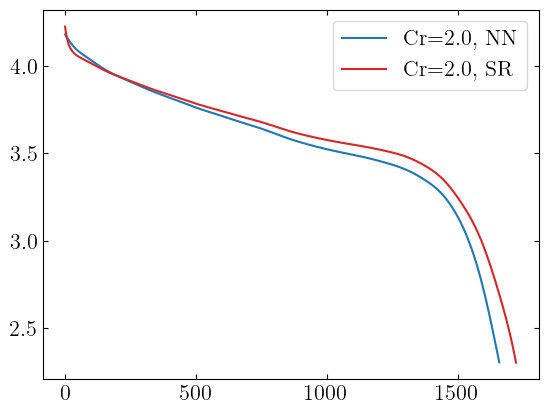

In [22]:


def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True, mode = 'DC', NN = False):
    
    t = np.arange(0, 2 * int(3600 / C_rate), DT)
    if discharge:
        print(f"Simulating discharge at C-rate: {C_rate}x")
    else:
        C_rate = -C_rate
        print(f"Simulating charge at C-rate: {C_rate}x")

    if mode == 'pulse':
        def I_interp(t):
            return pulse_current_profile(t, C_rate)
    else:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity
        I_interp = interp1d(t, i, fill_value="extrapolate")

    i = I_interp(t)
    if not discharge:
        #i = -i
        soc0 = 0
    else:        
        soc0 = 1

    print(f"Initial conditions: SOC={soc0}, U1={U0}")
    def dSOC(SOC, t, C_rate=C_rate, u_par=u_par):
        I_t = I_interp(t)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    #plt.show()
    soc_interp = interp1d(t,SOC_t,bounds_error=False,fill_value=(SOC_t[0], SOC_t[-1]))

    def dU(V_1, t, soc_int = soc_interp, d = u_par, NN = NN):
        I_t = pulse_current_profile(t, C_rate)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1(np.abs(C_rate), d, SOC_t, NN = NN)
        C = C1(np.abs(C_rate), d, SOC_t, NN = NN)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par, NN = NN):
        SOC_t = soc_int(t)
        return k(np.abs(C_rate), d, SOC_t, NN = NN)*d

    # Solve ODE
    

    def ECM_system(y, t, u_par, NN = NN):

        SOC, U1 = y
        #if t == 0:
            #print(f"Initial conditions: SOC={SOC}, U1={U1}")

        I_t = I_interp(t)

        if not discharge:

            SOC_eff = 1 - SOC

        else:

            SOC_eff = SOC
        R = R1(np.abs(C_rate), u_par, SOC_eff, NN = NN)
        C = C1(np.abs(C_rate), u_par, SOC_eff, NN = NN)
        dSOC_dt = -I_t / Q0

        dU1_dt = -U1 / (R * C) + I_t / C

        return [dSOC_dt, dU1_dt]

    U1 = scipy.integrate.odeint(dU, U0, t).flatten()
    y0 = [soc0, U0]

    sol = scipy.integrate.odeint(ECM_system, y0, t, args=(u_par,))

    SOC_t = sol[:, 0]

    U1 = sol[:, 1]

    U = U1 #+ U2
    # Voltage model
    R0_vals = []
    for s in SOC_t:
        R0_vals.append(R0(np.abs(C_rate),u_par,s, NN = NN))
    eta_model =  i*R0_vals + U
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model

    if not discharge:
        valid_inds = V_B< 5.5
    else:
        valid_inds = V_B> 2.3
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = I_interp(t)

    return V_B,soc, Ue,i ,t#, mech(t)


for C_rate in np.arange(2, 2.5, 0.5):
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, mode = 'DC', NN = True)
    plt.plot(t, V_B, label=f'Cr={C_rate}, NN', color = COLORS[0])
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, mode = 'DC', NN = False)
    plt.plot(t, V_B, label=f'Cr={C_rate}, SR', color = COLORS[1])
#plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
plt.legend()
plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')


Simulating charge at C-rate: -3x
Initial conditions: SOC=0, U1=0


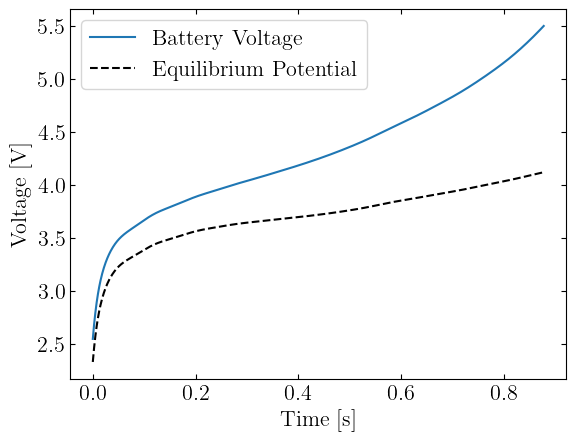

In [23]:
V_B,soc,Ue,i,t = ECM_solve_du(3.7,3, discharge = False, mode = 'DC', NN = True)
f, ax = plt.subplots()
#ax2 = ax.twinx()
#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
#ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(soc, V_B, label='Battery Voltage') 
ax.plot(soc,Ue, 'black', ls = '--',label='Equilibrium Potential')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax.legend()

Simulating charge at C-rate: -2x
Initial conditions: SOC=0, U1=0


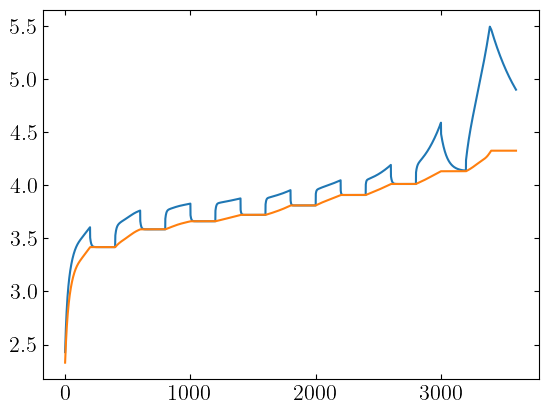

In [25]:
V_B,soc,Ue,i,t = ECM_solve_du(1,2, discharge = False, mode = 'pulse')
f, ax = plt.subplots()

#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(t, Ue, label='Battery Voltage') 
#plt.plot(t, soc, label=f'C={C_rate}x')

In [27]:
df_true = read_data('merged_DC_hyper', symbolic=False)
display(df_true.head())
split_train = int(df_true['trajectory'].max() * 0.8)

df_test = df_true[df_true['trajectory'] >= split_train]
df_train = df_true[df_true['trajectory'] < split_train]

print(f'F_max in test set: {df_true["F"][df_true['t'] == 0].max():.2f} ') 

,u_par,C,t,V,I,F,u,Ue,soc,eta,pulse,trajectory
0,29.9,1.6,0,4.253899,7.965145,0.146418,-4.297602,4.324997,0.999999,0.071098,False,0
1,29.9,1.6,1,4.233293,7.965145,0.146425,-4.297602,4.323647,0.999556,0.090353,False,0
2,29.9,1.6,2,4.221503,7.965145,0.146433,-4.297602,4.322293,0.999111,0.100790,False,0
3,29.9,1.6,3,4.212291,7.965145,0.146441,-4.297602,4.320940,0.998667,0.108649,False,0
4,29.9,1.6,4,4.204559,7.965145,0.146448,-4.297602,4.319587,0.998222,0.115027,False,0


F_max in test set: 0.15 


Selected trajectory index: 101
Selected trajectory parameters: C=2.1, u_par=0.6
Simulating discharge at C-rate: 2.1x
Initial conditions: SOC=1, U1=0
Simulating discharge at C-rate: 2.1x
Initial conditions: SOC=1, U1=0


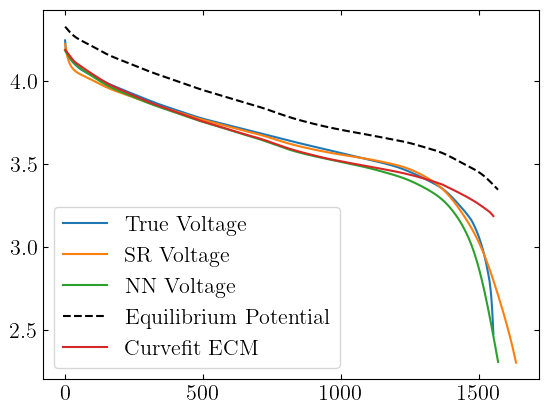

In [33]:
u_C_pairs = df_test.loc[df_true['t'] == 0, ['u_par', 'C', 'trajectory']]


C = 2

traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) + split_train

print(f"Selected trajectory index: {traj}")
C_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'C'].values[0]
u_par_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'u_par'].values[0]

print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext}")

plt.plot(df_true.loc[df_true['trajectory'] == traj, 't'], df_true.loc[df_true['trajectory'] == traj, 'V'], label='True Voltage')


V_B,soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC')
plt.plot(t, V_B, label='SR Voltage')
V_B,soc,Ue,i,t= ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = True)
plt.plot(t, V_B, label='NN Voltage')
plt.plot(t, Ue, label='Equilibrium Potential', color = 'k', ls = '--')

VB_fix, t = parameter_estimation_curvefit(df_true.loc[df_true['trajectory'] == traj])
plt.plot(t, VB_fix, label='Curvefit ECM')
#plt.plot(t[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], V_B[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], label='NN Voltage')
plt.legend()